## Дизайн AB-теста

Проведение экспериментов — одна из основных и регулярных задач продуктового аналитика. Этот ноутбук рассматривает процесс дизайна и сложности, с которыми можно столкнуться, решая задачу (с фокусом на метрики).

После того, как сформулирована гипотеза, аналитик должен ответить на следующие вопросы:
1. Какая единица рандомизации эксперимента?
2. На какой сегмент будет запущен эксперимент?
3. Какой нужен размер выборки?
4. Как долго будет идти эксперимент?

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import norm

import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 14, 'axes.titlepad': 16,
    'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False,
})

import warnings
warnings.filterwarnings('ignore')

### 1. Единица рандомизации эксперимента

Классические AB-тесты принято запускать с поюзерным разбиением. Однако, такой формат тестирования подходит не для всех гипотез. К другим распространенным подходам относят:
- Свитчбек-тесты — единица рандомизации время или время-пространство;
- Региональные (гео) тесты — единица рандомизации город или регион.

Мы переходим к другим единицам рандомизации, когда проведение поюзерных тестов может исказить результаты из-за сетевого эффекта.

#### Почему сетевой эффект ломает поюзерный тест: SUTVA?

У корректного A/B-теста есть предпосылка с именем — **SUTVA** (Stable Unit Treatment Value Assumption): исход конкретного юнита зависит только от того, какой вариант достался **ему**, и не зависит от того, какие варианты достались остальным. При ее нарушении эффект перестает быть честно замеренным.

Два канонических нарушения:

**Социальный граф.** Тестируем новый формат ленты. Пользователь из теста активнее постит -> его друзья из контроля видят больше контента —> контроль увеличивает активность. Эффект измеряется заниженным: мы сравниваем тест не с вариантом без фичи, а с версией, на которую фича также оказала воздействие.

**Общий пул ресурса — маркетплейсы, такси, доставка.** Предложение (водители, курьеры, товары) у групп **общее**. Фича подняла спрос в тестовой группе -> тестовые пользователи забрали больше водителей -> контрольным досталось меньше -> в контроле выросли время подачи и отмены. Метрика теста выросла *за счет* контроля: часть эффекта — каннибализация дефицитного ресурса, которая исчезнет при раскатке на 100%.


**Правило**: если юниты конкурируют за общий ресурс или общаются между собой — поюзерная рандомизация дает смещенную оценку. Для решения этой проблемы придуманы свитчбеки (в слоте времени либо все с фичей, либо все без) и гео-тесты (рынок целиком в одной группе): они восстанавливают SUTVA, платя за это ростом дисперсии и сложностью дизайна эксперимента.

### 2. Сегмент, который попадет в тест

Определяется:
- гипотезой (если она направлена на конкретную группу пользователей);
- местом фичи в продукте (где именно возникает взаимодействие).

Разбиение пользователей можно начинать в момент, когда они сталкиваются с экспериментируемым элементом. Например, если мы тестируем пошаговое оформление покупки вместо единой формы, в эксперимент попадут только пользователи, начавшие процесс оформления.

### 3. Размер выборки

Способ определения размера выборки зависит от критерия, который будем применять к оценке результатов.
Наиболее распространенный подход — расчёт через MDE. При этом в формуле используются квантильные значения стандартного нормального распределения (z-критерий).

Для определения размера выборки через MDE нужно задать:
- размер эффекта, который мы хотим задетектировать (MDE);
- уровни ошибок I и II рода;
- дисперсию метрики (базовый показатель конверсии для конверсий).

**Для среднего**:

$$
n \;=\; \frac{2\,\sigma^2 \,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$

**Для доли** (бинарная метрика):

$$
n \;=\; \frac{2\,p(1-p)\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$

- Формулы указаны для групп одинакового размера (50/50) и двустороннего критерия;
- n — размер одной группы.

### 4. Длительность эксперимента

Зависит от размера выборки. Правильный подход — на пред периоде симулировать накопление уникальных пользователей, взаимодействовавших с функционалом, и вернуть число дней, за которое собрался нужный объем.

### Разберем чуть подробнее этап контакта пользователя с тестовым функционалом

#### Exposure: убираем шум тех, на кого фича не влияет

**Exposure** — момент, когда пользователь действительно сталкивается с изменением: открыл экран, где находится фича. Рандомизировать можно раньше, например всех, кто зашел в приложение, но фичу увидят не все.

**Пример.** Добавляем блок рекомендаций на экран «Избранное». За время теста на этот экран заходит $s = 10\%$ пользователей приложения. У них конверсия в покупку $p_{exp} = 15\%$, у остальных $4\%$. Ожидаем, что блок поднимет конверсию увидевших его на $\Delta = 1.5$ п.п.

Размер выборки определяется отношением дисперсии метрики к эффекту:

$$
n = \frac{(z_{1-\alpha/2} + z_{1-\beta})^2 \cdot 2\sigma^2}{\text{эффект}^2} \;\propto\; \frac{\sigma^2}{\text{эффект}^2}.
$$

*Вариант 1: считаем по exposure.* В тест попадают только пользователи, зашедшие в «Избранное». 

$$
\text{эффект} = \Delta = 0.015, \qquad \sigma^2_{exp} = p_{exp}(1-p_{exp}) = 0.15 \cdot 0.85 \approx 0.128, \qquad \frac{\sigma^2_{exp}}{\Delta^2} \approx 570.
$$

*Вариант 2: считаем всех рандомизированных.* 90% группы блок не видели, поэтому эффект на всю группу равен $s \cdot \Delta$. Дисперсия считается по всей группе с конверсией $p = 0.1 \cdot 0.15 + 0.9 \cdot 0.04 \approx 5.1\%$:

$$
\text{эффект} = s \cdot \Delta = 0.0015, \qquad \sigma^2_{все} = p(1-p) = 0.051 \cdot 0.949 \approx 0.048, \qquad \frac{\sigma^2_{все}}{(s\Delta)^2} \approx 21\,500.
$$

Что произошло с дисперсией? Неувидевшие уменьшили эффект в 10 раз, а дисперсию всего в 2.6 раза. Дисперсия относительно эффекта выросла в $21\,500 / 570 \approx 38$ раз. Сигнал несут только 10% пользователей, а шум вносят все.    
Анализ только exposed пользователей исключает из оценки тех пользователей, для которых treatment заведомо не может проявиться (это допустимо только если exposure не является следствием treatment):

$$
n_{exp} \approx 7.85 \cdot 2 \cdot 0.128 / 0.015^2 \approx 8\,900,
\qquad
n_{все} \approx 7.85 \cdot 2 \cdot 0.048 / 0.0015^2 \approx 340\,000 \text{ на группу}.
$$

Что это значит для времени теста? Пользователи, у которых был exposure, набираются в $1/s = 10$ раз медленнее: чтобы 8 900 человек зашли в «Избранное», в приложение должно зайти около 89 000. Поэтому по времени выигрыш составляет $38 / 10 \approx 3.8$ раза.

**Правило:** фиксируйте точку exposure как можно ближе к изменению. Контрольную группу отбирают по тому же условию: пользователи, которые зашли в «Избранное», но увидели старую версию экрана. Иначе группы окажутся несопоставимыми.

*Здесь $7.85 = (1.96 + 0.84)^2$ для $\alpha = 0.05$ и мощности 80%.*

### 🔎 Пример: дизайн A/B-теста для мобильной игры

**Легенда**  
Представим, что мы аналитики в команде мобильной игры. К нам пришел продакт и просит провести дизайн эксперимента — мы усложняем уровни игры, начиная с 10 уровня, т.к. хотим вырастить средний чек (пользователям будет сложнее пройти дальше, поэтому они будут покупать более дорогие и эффективные атрибуты).

**Гипотеза** — усложнение прохождения игры, начиная с 10 уровня, увеличит средний чек покупки как минимум на 2.5%.

1. Единица рандомизации — поюзерный
2. Сегмент, который попадет в тест — 9+ уровень
3. Размер выборки — считаем ниже

In [6]:
df = pd.read_csv('data/seminar_3_mobile_game.csv')

df.head()

,date,user_id,level,event_id,purchase_amount
0,2025-08-01,1,4,8,NaN
1,2025-08-01,1,4,13,NaN
2,2025-08-01,1,4,12,NaN
3,2025-08-01,1,4,8,NaN
4,2025-08-01,2,1,3,NaN


In [7]:
df.shape

(2168137, 5)

In [8]:
df.user_id.nunique()

20000

In [9]:
df_10_lvl = df[df['level'] >= 9].reset_index(drop=True)

Покупка — event_id = 10

In [10]:
df_10_lvl[df_10_lvl['event_id'] == 10].purchase_amount.mean()

25.839738471100063

In [11]:
def sample_size_mean(metric_series, mde, alpha=0.05, power=0.8, two_sided=True):

    var = np.var(metric_series, ddof=1)

    if two_sided:
        z_alpha = norm.ppf(1 - alpha/2)
    else:
        z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)

    n = (2 * var * (z_alpha + z_beta) ** 2) / (mde ** 2)

    return int(np.ceil(n))

In [12]:
sample_size_mean(df_10_lvl[df_10_lvl['event_id'] == 10].purchase_amount,
                 df_10_lvl[df_10_lvl['event_id'] == 10].purchase_amount.mean() * 0.025,
                 alpha=0.05, power=0.8, two_sided=True)

8832

### Не кажется ли вам, что в дизайне есть что-то подозрительное?

Посмотрите ещё раз на то, что мы только что посчитали, и на пункт 1 дизайна. Что именно мы подставили в формулу и кого собираемся рандомизировать?

#### Средний чек — ratio-метрика

Мы рандомизировали **пользователей**, а размер выборки только что посчитали по **покупкам**: в `sample_size_mean` ушли строки-покупки, как будто каждая из них — независимое наблюдение. Это не так. Все покупки одного игрока сделаны одним человеком: если он предпочитает дорогие атрибуты, все его чеки выше среднего, если дешевые — все ниже. Чеки внутри пользователя похожи друг на друга, и десятая покупка того же игрока добавляет гораздо меньше новой информации, чем первая покупка нового.

Формула размера выборки этого не знает. Она считает, что независимых наблюдений столько, сколько строк, и получает дисперсию среднего заниженной. Дальше цепочка: заниженная дисперсия -> слишком узкий доверительный интервал -> слишком маленький размер выборки -> в реальном тесте результат будет «прокрашиваться» чаще, чем в 5% случаев без эффекта. Ошибку мы не заметим: тест просто станет чаще находить то, чего нет.

Средний чек = выручка / число покупок. В знаменателе стоят не пользователи, а события. Такие метрики называют **ratio-метриками**, и считать по ним размер выборки и результат нужно иначе.

А если рассчитать средний чек на пользователя?

In [13]:
df_10_lvl['is_purchase'] = df_10_lvl['event_id'] == 10

In [14]:
df_users_ratio = df_10_lvl.groupby(['user_id'], as_index=False) \
    .agg(sum_amt=('purchase_amount', 'sum'),
         purchases=('is_purchase', 'sum'))

In [15]:
df_users_ratio['avg_check_per_user'] = (df_users_ratio['sum_amt'] / df_users_ratio['purchases']).fillna(0)

In [16]:
df_users_ratio.isna().sum()

user_id               0
sum_amt               0
purchases             0
avg_check_per_user    0
dtype: int64

In [17]:
sample_size_mean(df_users_ratio.avg_check_per_user,
                 df_users_ratio.avg_check_per_user.mean() * 0.025,
                 alpha=0.05, power=0.8, two_sided=True)

11069

In [18]:
df_users_ratio.avg_check_per_user.mean()

20.99609802830992

In [19]:
df_10_lvl[df_10_lvl['event_id'] == 10].purchase_amount.mean()

25.839738471100063

## Ratio-метрики

#### Что мы только что посчитали

Два числа выше — две разные метрики, хотя обе называются «средний чек»:

1. `purchase_amount.mean()` по покупкам — вся выручка / все покупки. Каждая покупка весит одинаково. Это то, что бизнес называет средним чеком, и то, что связано с деньгами: выручка = число покупок x средний чек.
2. `avg_check_per_user.mean()` — среднее по пользователям от их личных средних чеков. Каждый пользователь весит одинаково, сколько бы он ни купил. Игрок с одной покупкой на 1 000 и игрок с девятью покупками по 100 в первой метрике дают средний чек $(1000 + 900) / 10 = 190$, во второй — $(1000 + 100) / 2 = 550$.

К тому же `fillna(0)` добавил пользователей без покупок как пользователей «с чеком 0». Таких не существует: у того, кто не покупал, чек не определен. Из-за этого среднее по колонке смешало конверсию в покупку и размер чека. Если усложнение уровней заставит покупать тех, кто раньше не покупал, эта метрика сдвинется, хотя ни один чек не изменился.

Поэтому «та же метрика на уровне пользователя» — на самом деле другая. Поюзерный пересчет меняет веса и отвечает на другой вопрос: не «сколько стоит покупка», а «какой чек у типичного игрока». Обе метрики законны, но гипотеза продакта сформулирована про первую.

#### Как перейти на уровень пользователя, не меняя метрику

Правильный переход другой. Для каждого игрока $u$ считаем две суммы: выручку $X_u$ и число покупок $Y_u$. Тогда

$$
\text{средний чек} = \frac{\sum_u X_u}{\sum_u Y_u} = \frac{\bar{X}}{\bar{Y}}.
$$

Число то же самое, что в пункте 1: сумма выручки по пользователям — это вся выручка, сумма покупок — все покупки. Но теперь наблюдение — пара $(X_u, Y_u)$ на пользователя. Пары независимы, потому что рандомизировали именно пользователей, и с ними можно работать честно.

**Ratio-метрика** — отношение двух средних по единицам рандомизации:

$$
M = \frac{\sum_u X_u}{\sum_u Y_u} = \frac{\bar{X}}{\bar{Y}}.
$$

Признак: рандомизировали пользователей, а в знаменателе события. Примеры: средний чек (выручка / покупки), CTR (клики / показы), средняя длина сессии (время / сессии), доля отмен (отмены / заказы).

**Зачем они нужны.** Ratio-метрика нормирует результат на активность и отделяет **качество** от **объема**. CTR показывает, насколько хороши рекомендации, независимо от того, сколько показов увидел пользователь. Средний чек показывает, сколько стоит покупка, независимо от того, сколько покупок сделано. Поюзерные метрики эти две вещи смешивают. Поэтому ratio-метрики часто точнее отвечают на вопрос, который задает команда.

#### Почему у отношения другая дисперсия

Мы получили независимость и вместе с ней новую проблему: метрика — не среднее, а отношение двух средних, и знаменатель случайный.

Представим, что мы провели A/A-тест сто раз. В каждом разбиении средняя выручка на игрока $\bar{X}$ чуть другая, среднее число покупок $\bar{Y}$ тоже чуть другое, и средний чек $\bar{X}/\bar{Y}$ прыгает из-за обоих. Причем прыгает не как попало: у игрока, который много покупает, и выручка большая, то есть $X_u$ и $Y_u$ растут вместе. Когда в группу случайно попало больше активных игроков, вырастут и числитель, и знаменатель, и отношение сдвинется меньше, чем если бы они двигались независимо.

Дисперсия отношения складывается из трех частей: разброс числителя, разброс знаменателя и связь между ними. Обычная формула дисперсии среднего знает только первую. Поэтому подставить $\bar{X}/\bar{Y}$ в `sample_size_mean` нельзя — нужен способ посчитать дисперсию отношения целиком.

Отказаться от ratio-метрик нельзя, поэтому для них разработаны три подхода.

**1. Замена на поюзерную метрику.**

Заменить ratio на метрику, у которой в знаменателе число пользователей. Например, вместо среднего чека брать ARPU (выручка / число пользователей).

Плюсы:
- наблюдения независимы, работает обычный t-тест без поправок.

Минусы:
- это другая метрика, и ее движение может не совпадать с исходной. Если часть игроков просто начнет покупать чаще, ARPU вырастет без роста среднего чека;
- поюзерная метрика снова смешивает качество и объем, то есть теряется то, ради чего брали ratio.

**2. Дельта-метод.**

[Оригинальная статья](https://alexdeng.github.io/public/files/kdd2018-dm.pdf) о применении метода в A/B тестировании.

Дельта-метод оценивает дисперсию отношения через разложение Тейлора первого порядка и собирает ровно три части, о которых шла речь выше. Дисперсия ratio в расчете на одного пользователя:

$$
\sigma^2_{ratio} = \frac{\mathrm{Var}(X_u)}{\mu_Y^2} - 2\frac{\mu_X}{\mu_Y^3}\mathrm{Cov}(X_u, Y_u) + \frac{\mu_X^2}{\mu_Y^4}\mathrm{Var}(Y_u)
$$

где $X_u$, $Y_u$ — выручка и число покупок одного пользователя. Первое слагаемое — разброс выручки, третье — разброс числа покупок, среднее с минусом — их связь: она положительна, и потому уменьшает итоговую дисперсию. Дисперсия оценки на группе из $n$ пользователей равна $\mathrm{Var}(\bar{X}/\bar{Y}) \approx \sigma^2_{ratio} / n$. Размер выборки на группу:

$$
n = \frac{2 \cdot \sigma^2_{ratio} \cdot \big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}.
$$

Плюсы:
- работаем с исходной метрикой;
- быстрый расчет по агрегатам, хорошо подходит для больших выборок.

Минусы:
- асимптотическое приближение, на малых $n$ может быть неточным;
- ломается, когда знаменатель на единицу рандомизации мал или часто нулевой. Так бывает в свитчбек-тестах с маленькими гео и короткими временными слотами, где в слоте может быть несколько заказов или ни одного.

**3. Линеаризация.**

[Оригинальная статья](https://www.researchgate.net/profile/Roman-Budylin/publication/322969314_Consistent_Transformation_of_Ratio_Metrics_for_Efficient_Online_Controlled_Experiments/links/5b054bbb45851588c6d4a1aa/Consistent-Transformation-of-Ratio-Metrics-for-Efficient-Online-Controlled-Experiments.pdf) от Яндекса.

Для каждого пользователя считается новая метрика, среднее которой равно исходному ratio:

$$
Z_u = \frac{\bar X}{\bar Y} + \frac{1}{\bar Y}\left( X_u - \frac{\bar X}{\bar Y}\, Y_u \right).
$$

Прочитать формулу можно так. Обозначим $k = \bar X / \bar Y$ — средний чек в контроле. Тогда $X_u - k\,Y_u$ — это сколько выручки игрок принес сверх того, что принес бы при контрольном среднем чеке: положительное число, если его покупки дороже средних, отрицательное — если дешевле, ноль — если ровно средние. Деление на $\bar Y$ возвращает величину в единицы чека. В контроле среднее $Z_u$ равно $k$, в тесте — $k$ плюс прирост среднего чека. Так отношение превратилось в обычную поюзерную метрику «вклад игрока в средний чек», и к ней применима формула для среднего:

$$
n = \frac{2 \cdot \mathrm{Var}(Z) \cdot \big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}.
$$

Это тот же дельта-метод, записанный через поюзерную метрику: $\mathrm{Var}(Z)$ в точности равна $\sigma^2_{ratio}$, поэтому оба подхода дают одинаковый размер выборки. Разница в том, что у нас появляется значение метрики для каждого пользователя.

Плюсы:
- линеаризованная метрика ведет себя как обычная поюзерная (вместо пользователя может быть любая единица рандомизации): к ней применимы t-тест и все, что работает со средним;
- к ней можно применять методы снижения дисперсии (CUPED), бутстрап по пользователям, стратификацию;
- просто реализовать.

Минусы:
- те же, что у дельта-метода: асимптотика и чувствительность к выбросам и к малым знаменателям;
- значения $Z_u$ не имеют бизнес-смысла по отдельности, интерпретируется только их среднее.

#### Как посчитать результат теста по ratio-метрике

Порядок действий на этапе анализа:

1. Агрегируем данные до уровня пользователя: $X_u$ — выручка, $Y_u$ — число покупок, отдельно для теста и контроля.
2. Считаем $k = \sum X_u / \sum Y_u$ **по контрольной группе** и используем это $k$ для линеаризации обеих групп. Если считать $k$ в каждой группе отдельно, среднее $Z_u$ в каждой из них окажется равным ее собственному среднему чеку, но разность средних потеряет корректную дисперсию.
3. Считаем $Z_u$ для каждого пользователя обеих групп и сравниваем средние t-тестом Уэлча, как обычную поюзерную метрику.
4. Разность средних $Z$ — это оценка прироста среднего чека в рублях; доверительный интервал t-теста переносится на нее напрямую. Относительный эффект — разность, деленная на $k$.

Тот же результат даст дельта-метод: разность средних чеков двух групп и ее стандартная ошибка $\sqrt{\sigma^2_{ratio, A}/n_A + \sigma^2_{ratio, B}/n_B}$.

**Итого.** Если нужна исходная ratio-метрика, выбирайте между дельта-методом и линеаризацией: результат один и тот же, линеаризация удобнее, когда дальше нужны CUPED или бутстрап. Замена на поюзерную метрику корректна статистически, но отвечает на другой вопрос.

In [20]:
def sample_size_ratio_delta(num, den, mde, alpha=0.05, power=0.8, two_sided=True):
    mu_X = num.mean()
    mu_Y = den.mean()

    var_X = np.var(num, ddof=1)
    var_Y = np.var(den, ddof=1)
    cov_XY = np.cov(num, den, ddof=1)[0,1]

    var_ratio = (var_X / mu_Y**2
                 - 2 * mu_X * cov_XY / mu_Y**3
                 + (mu_X**2) * var_Y / mu_Y**4)

    if two_sided:
        z_alpha = norm.ppf(1 - alpha/2)
    else:
        z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)

    n = (2 * var_ratio * (z_alpha + z_beta)**2) / (mde**2)
    return int(np.ceil(n))

In [51]:
sample_size_ratio_delta(df_users_ratio.sum_amt, df_users_ratio.purchases,
                        (df_users_ratio['sum_amt'].sum() / df_users_ratio['purchases'].sum()) * 0.025,
                        alpha=0.05, power=0.8, two_sided=True)

3699

In [52]:
def ratio_linearise(num, den):
    num_mean = np.mean(num)
    den_mean = np.mean(den)
    z_lin = num_mean / den_mean + 1 / den_mean * (num - num_mean / den_mean * den)
    
    return z_lin

z = ratio_linearise(df_users_ratio.sum_amt, df_users_ratio.purchases)
mde_abs = (df_users_ratio['sum_amt'].sum() / df_users_ratio['purchases'].sum()) * 0.025

n_lin = sample_size_mean(z, mde_abs, alpha=0.05, power=0.8, two_sided=True)
n_delta = sample_size_ratio_delta(df_users_ratio.sum_amt, df_users_ratio.purchases,
                            mde_abs, alpha=0.05, power=0.8, two_sided=True)

print(f'Линеаризация: n = {n_lin:,}'.replace(',', ' '))
print(f'Дельта-метод: n = {n_delta:,}'.replace(',', ' '))

Линеаризация: n = 3 699
Дельта-метод: n = 3 699


### Длительность: наивная и правильная оценка

Базовый способ — средние уникальные пользователи в день:

In [54]:
unique_users_per_day = df.user_id.nunique() / df['date'].nunique()
unique_users_per_day

645.1612903225806

In [55]:
n = sample_size_ratio_delta(df_users_ratio.sum_amt, df_users_ratio.purchases,
                        (df_users_ratio['sum_amt'].sum() / df_users_ratio['purchases'].sum()) * 0.025,
                        alpha=0.05, power=0.8, two_sided=True)

In [56]:
n * 2 / unique_users_per_day

11.4669

In [57]:
def cumulative_unique_users(df, date_col='date', user_col='user_id'):
    dates = pd.to_datetime(df[date_col])
    first_seen = dates.groupby(df[user_col]).min()
    day_index = (first_seen - first_seen.min()).dt.days + 1
    return day_index.value_counts().sort_index().cumsum()


cum_users = cumulative_unique_users(df_10_lvl)
cum_users.head(10)

date
1       17
2       67
3      152
4      289
5      488
6      745
7     1096
8     1498
9     2005
10    2535
Name: count, dtype: int64

### Обратная задача: какой эффект мы вообще успеем поймать

На практике чаще спрашивают не «сколько нужно данных», а «у нас есть N дней — что мы за них увидим». Это то же уравнение, решённое относительно MDE:

$$
\text{MDE} \;=\; \sqrt{\frac{2\,\sigma^2\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{n}}, \qquad n = \frac{\text{пользователей в день} \times \text{дни}}{2}
$$

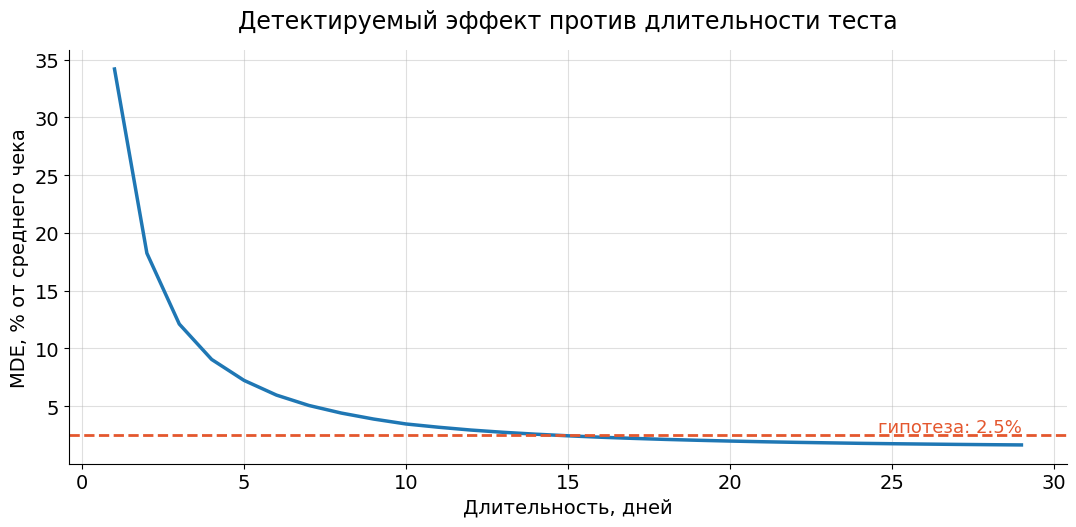

In [35]:
def mde_from_n(metric_series, n, alpha=0.05, power=0.8, two_sided=True):
    var = np.var(metric_series, ddof=1)
    z_alpha = norm.ppf(1 - alpha/2) if two_sided else norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)
    return np.sqrt(2 * var * (z_alpha + z_beta) ** 2 / n)


base_aov = df_users_ratio['sum_amt'].sum() / df_users_ratio['purchases'].sum()
z = ratio_linearise(df_users_ratio.sum_amt, df_users_ratio.purchases)

days_grid = cum_users.index[cum_users.index <= 30]
mde_rel = [mde_from_n(z, cum_users[d] / 2) / base_aov for d in days_grid]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(days_grid, np.array(mde_rel) * 100, lw=2.5)
ax.axhline(2.5, ls='--', color='#E4572E', lw=2)
ax.text(days_grid[-1], 2.8, 'гипотеза: 2.5%', ha='right', color='#E4572E', fontsize=13)
ax.set_title('Детектируемый эффект против длительности теста')
ax.set_xlabel('Длительность, дней'); ax.set_ylabel('MDE, % от среднего чека')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

## Доп блок: Свитчбек-тесты

При свитчбек-тестировании мы чередуем показ тестового и контрольного варианта, рандомизируя их по времени (слот зависит от тестируемой фичи и специфики продукта, может быть как 5 минут, так и 1 час). Также распространен вариант, в котором переключение происходит не только по времени, но и по пространству (такой подход часто используют в такси, где пространственной единицей становится [гексагон](https://h3geo.org/)).

В контексте курса нам интересны свитчбеки, т.к. почти все метрики для такого дизайна превращаются в Ratio на уровне слота. Даже по-юзерные, ведь теперь в один слот попадет сразу несколько пользователей, а числитель и знаменатель метрики слота приобретут зависимость. Тот же ARPU примет вид:

$$
ARPU_{slot} \;=\; \frac{\text{сумма revenue в слоте}}{\text{число активных пользователей в слоте}}
$$

Поэтому в таких тестах не обойтись без рассмотренных выше подходов.

**Цена свитчбека.** Единиц наблюдения становится радикально меньше: было 500 000 пользователей — стало 336 слотов по часу за две недели. Дисперсия оценки растет соответственно, а значит растет и MDE: свитчбек ловит только крупные эффекты. Плюс появляются свои болезни — эффекты переноса между соседними слотами (carryover: водитель, «подтянутый» тестовым слотом, работает и в контрольном) и необходимость буферных зон. Свитчбек — не бесплатное решение проблемы SUTVA, а обмен смещения на дисперсию.

In [36]:
df_taxi = pd.read_csv('data/hw_2_taxi.csv')

df_taxi.head()

,date,time,order_uid,order_status,passenger_id,vehicle_type,pickup_location,drop_location,ETA,RTA,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,fare,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-01-01,00:19:34,2a11faf27f77eae8,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,9.0,10.8,...,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash
1,2024-01-01,01:35:18,33ed1f6bad78bdc8,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,6.0,8.5,...,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01,01:37:50,e2fc1fc520e93b85,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,6.0,7.4,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,01:48:03,a130fd507acf7804,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.0,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,01:49:56,cae2db8689a422fa,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,3.0,6.2,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df_taxi['date'] = pd.to_datetime(df_taxi['date'])
df_taxi['timestamp'] = pd.to_datetime(df_taxi['date'].dt.strftime('%Y-%m-%d') + ' ' + df_taxi['time'].astype(str))

In [38]:
df_taxi.timestamp.max()

Timestamp('2024-12-30 23:36:11')

Давайте возьмем только декабрьские данные на дизайн

In [39]:
df_taxi_dec = df_taxi[df_taxi['timestamp'] >= pd.Timestamp(2024, 12, 1)].reset_index(drop=True)

In [40]:
df_taxi_dec['is_ride'] = df_taxi_dec['order_status'] == 'Completed'

Получаем датафрейм с агрегированными данными по временным слотам

In [41]:
def get_switchback_units(df, num, den, num_agg, den_agg, time_col, time_slot_min):
    
    df_units = df \
        .set_index(time_col) \
        .groupby(pd.Grouper(freq=f'{time_slot_min}min')) \
        .agg({num:num_agg,
              den:den_agg}) \
        .reset_index() \
        .rename(columns={time_col:'unit_start'})
    
    df_units['unit_end'] = df_units['unit_start'] + pd.Timedelta(minutes=time_slot_min)

    return df_units

In [42]:
df_taxi_dec_time_units = get_switchback_units(df_taxi_dec, 'is_ride', 'order_uid', 'sum', 'nunique', 'timestamp', 30)

df_taxi_dec_time_units.head()

,unit_start,is_ride,order_uid,unit_end
0,2024-12-01 00:00:00,1,2,2024-12-01 00:30:00
1,2024-12-01 00:30:00,0,0,2024-12-01 01:00:00
2,2024-12-01 01:00:00,0,1,2024-12-01 01:30:00
3,2024-12-01 01:30:00,1,1,2024-12-01 02:00:00
4,2024-12-01 02:00:00,0,1,2024-12-01 02:30:00


Линеаризуем метрику

In [43]:
z_lin_CR = ratio_linearise(df_taxi_dec_time_units.is_ride, df_taxi_dec_time_units.order_uid)

z_lin_CR[:5]

0    0.593411
1    0.622122
2    0.548991
3    0.666542
4    0.548991
dtype: float64

Используем обычную формулу размера выборки через MDE для среднего, т.к. мы перешли к линеаризованной метрике на юнит. Заложим относительный эффект 4%

In [44]:
sample_size_mean(z_lin_CR, 0.04 * z_lin_CR.mean(), alpha=0.05, power=0.8, two_sided=True)

666

Не забывайте, что размер выборки, который мы получаем в данной формуле, возвращается к нам в единицах рандомизации! В этом примере — в числе 30-минуток. Поэтому, для расчета длительности теста в днях, будем делить полученное число на количество 30-минуток за день

In [45]:
n_group = sample_size_mean(z_lin_CR, 0.04 * z_lin_CR.mean(), alpha=0.05, power=0.8, two_sided=True)

n_group * 2 / (24 * 2)

27.75

Для детектирования относительного эффекта в 4% для метрики Completion Rate для свитчбека 30-минутки нам потребуется 28 дней